# Notebook Objectives

This notebook computes neural values for one session. For all sessions, we do the same in ```neural_value_RUN_all_sessions.py```, results shown in ```neural_value_all_sessions.ipynb```.

Results include:
* Neural value vs. behavior (last 3 outcomes, behavioral value, long history, etc)
* Change in neural value, etc

---
# Setup


In [2]:
from neural_value_helpers import *
from popy.config import COLORS

In [3]:
##% data loading
def load_mega_custom(monkey=None, area=None, subregion=None, downsample=True):
    # load data (meta session)
    floc = os.path.join(PATH, 'data', 'processed', 'neural_data', 'meta_rates_history')
    neural_dataset =  xr.open_dataset(floc + '/meta_rates.nc')

    if area is not None:
        neural_dataset = neural_dataset.sel(unit=neural_dataset.area == area)
    if subregion is not None:
        neural_dataset = neural_dataset.sel(unit=neural_dataset.subregion == subregion)

    if monkey is not None:
        neural_dataset = neural_dataset.sel(unit=neural_dataset.monkey == monkey)

    # use only time points of every .1 s
    if downsample:
        time_vector = neural_dataset.time.values
        time_vector = np.unique(np.round(time_vector, 1))  # round to 1 decimal place to avoid floating point issues
        neural_dataset = neural_dataset.sel(time=time_vector, method='nearest')

    # add coordinates (should be added during the dataset creation)
    neural_dataset = neural_dataset.assign_coords(R_1=('trial_id', [0 if hist in [0, 1, 2, 3] else 1 for hist in neural_dataset.history_of_feedback.values]))
    neural_dataset = neural_dataset.assign_coords(R_2=('trial_id', [0 if hist in [0, 1, 4, 5] else 1 for hist in neural_dataset.history_of_feedback.values]))
    neural_dataset = neural_dataset.assign_coords(R_3=('trial_id', [0 if hist in [0, 2, 4, 6] else 1 for hist in neural_dataset.history_of_feedback.values]))
    neural_dataset = neural_dataset.assign_coords(fb_sequence=('trial_id', neural_dataset.history_of_feedback.values))
    neural_dataset = neural_dataset.assign_coords(fb_sequence_m1=('trial_id', neural_dataset.history_of_feedback.values%4))
    neural_dataset = neural_dataset.assign_coords(time_m1=('time', neural_dataset.time.values + 7.5))

    # normalize firing rates (z-score) and remove units with low firing rates
    threshold = 1  # Hz
    units_to_remove = []
    normalized_data = np.zeros_like(neural_dataset.firing_rates.data)  # Create a copy to avoid modifying the original data
    for i, unit in enumerate(neural_dataset.unit.values):  # Loop through each neuron
        # Get all data for this neuron across trials and timepoints
        unit_data = neural_dataset.firing_rates.sel(unit=unit).values
        
        # Calculate mean and std across all values for this neuron
        mean_val = np.mean(unit_data)
        std_val = np.std(unit_data)
        
        # Z-score normalize and store in the output array
        if mean_val < threshold:
            units_to_remove.append(unit)
        elif std_val == 0:
            raise ValueError(f"Standard deviation is zero for unit {unit}. Not possible.")
        else:
            z_scored_data = (unit_data - mean_val) / std_val        
            normalized_data[:, i, :] = z_scored_data
    #neural_dataset.firing_rates.values = normalized_data
    neural_dataset['firing_rates'] = (neural_dataset.firing_rates.dims, normalized_data)

    neural_dataset = neural_dataset.sel(unit=~neural_dataset.unit.isin(units_to_remove))
    print(f"Removed {len(units_to_remove)} units with mean firing rate < {threshold} Hz")

    return neural_dataset

---
# Get the across time thing (alongside the decoding performance and projection, but in low resolution)

In [ ]:
neural_dataset_all = load_mega_custom(downsample=True)
target = 'R_1'  # target for the decoder, can be R_1, R_2, R_3, or switch

# create a new figure: the accuracies across areas

for subregion in np.unique(neural_dataset_all.subregion.values):
    neural_dataset_subregion = neural_dataset_all.sel(unit=neural_dataset_all.subregion==subregion)
    ## 1. plot monkey average
    #results, weights, data_projected, pvalue = time_resolved_decoder(neural_dataset, target='R_1', t_project=t_interest_fit)
    decodability_matrix, data_projected = time_resolved_decoder_all_time(neural_dataset_subregion, target=target, across_time=True)

    fig, axes = plot_across_time_decodability(projected_data=data_projected, decodability_matrix=decodability_matrix, vmin=0.6, vmax=.9, cmap='Greys')
    plt.suptitle(f'both monkeys {subregion}, decoding {target}', fontsize=10, y=1.02)
    fig.savefig(f'figs/neural_value/mega_session/KA&PO_mega_session_{subregion}_across_time_decodability.svg', bbox_inches='tight', transparent=True)
    plt.show()
    plt.close(fig)

    fig, ax = plot_projected_data(data_projected, t_interest_value=None, n_extra_trials=(-1, 0), xlim=[-5, 5], paper_format=True)
    
    ax.set_title(f'both monkeys {subregion} ')
    plt.show()
    plt.close(fig)

    '''## 2. prot per monkey
    for monkey in np.unique(neural_dataset_all.monkey.values):
        neural_dataset = neural_dataset_subregion.sel(unit=neural_dataset_subregion.monkey==monkey)
        #results, weights, data_projected, pvalue = time_resolved_decoder(neural_dataset, target='R_1', t_project=t_interest_fit)
        decodability_matrix, data_projected = time_resolved_decoder_all_time(neural_dataset, target='R_1', across_time=True)

        fig, axes = plot_across_time_decodability(projected_data=data_projected, decodability_matrix=decodability_matrix, vmin=0.1, vmax=.9)
        plt.suptitle(f'{monkey} {subregion}', fontsize=10, y=1.02)
        #fig.savefig(f'figs/neural_value/mega_session/{monkey}_mega_session_{subregion}_across_time_decodability.svg', bbox_inches='tight', transparent=True)
        plt.show()
        plt.close(fig)

        fig, ax = plot_projected_data(data_projected, t_interest_value=None, n_extra_trials=(-1, 0), xlim=[-5, 5], paper_format=True)
        ax.set_title(f'{monkey} {subregion}')
        plt.show()
        plt.close(fig)'''


# Get projections in high resolution

Removed 334 units with mean firing rate < 1 Hz


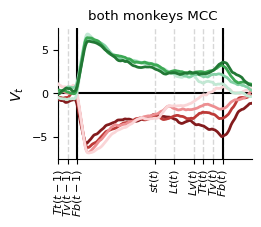

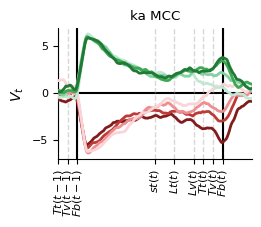

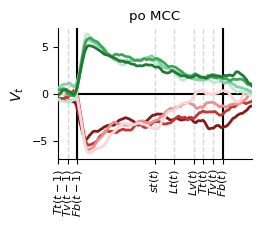

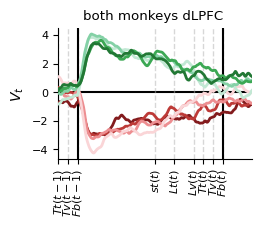

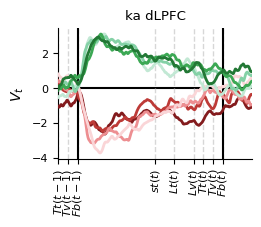

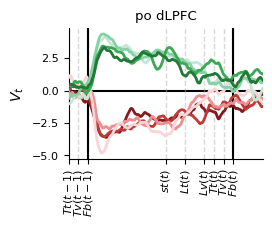

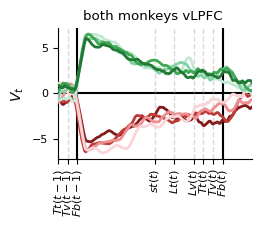

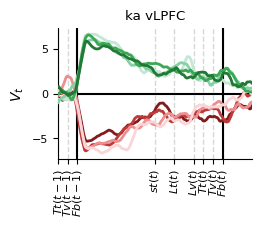

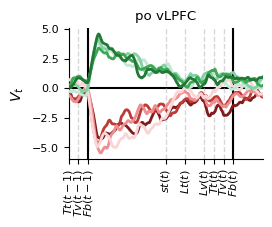

In [4]:
neural_dataset_all = load_mega_custom(downsample=False)

# create a new figure: the accuracies across areas

for subregion in np.unique(neural_dataset_all.subregion.values):
    neural_dataset_subregion = neural_dataset_all.sel(unit=neural_dataset_all.subregion==subregion)
    ## 1. plot monkey average
    #results, weights, data_projected, pvalue = time_resolved_decoder(neural_dataset, target='R_1', t_project=t_interest_fit)
    _, data_projected = time_resolved_decoder_all_time(neural_dataset_subregion, target='R_1', across_time=False)

    fig, ax = plot_projected_data(data_projected, t_interest_value=None, n_extra_trials=(-1, 0), xlim=[-5, 5], paper_format=True)
    ax.set_title(f'both monkeys {subregion} ')
    fig.savefig(f'figs/neural_value/mega_session/KA&PO_mega_session_{subregion}_projected_data.svg', bbox_inches='tight', transparent=True)
    plt.show()
    plt.close(fig)

    ## 2. prot per monkey
    for monkey in np.unique(neural_dataset_all.monkey.values):
        neural_dataset = neural_dataset_subregion.sel(unit=neural_dataset_subregion.monkey==monkey)
        #results, weights, data_projected, pvalue = time_resolved_decoder(neural_dataset, target='R_1', t_project=t_interest_fit)
        _, data_projected = time_resolved_decoder_all_time(neural_dataset, target='R_1', across_time=False)

        fig, ax = plot_projected_data(data_projected, t_interest_value=None, n_extra_trials=(-1, 0), xlim=[-5, 5], paper_format=True)
        ax.set_title(f'{monkey} {subregion}')
        fig.savefig(f'figs/neural_value/mega_session/{monkey}_mega_session_{subregion}_projected_data.svg', bbox_inches='tight', transparent=True)
        plt.show()
        plt.close(fig)


# analyse only the decoding performance (not the across time thing)

In [ ]:
neural_dataset_all = load_mega_custom(downsample=False)

# create a new figure: the accuracies across areas

decodabilities = {}
for subregion in np.unique(neural_dataset_all.subregion.values):
    neural_dataset_subregion = neural_dataset_all.sel(unit=neural_dataset_all.subregion==subregion)
    ## 1. plot monkey average
    #results, weights, data_projected, pvalue = time_resolved_decoder(neural_dataset, target='R_1', t_project=t_interest_fit)
    decodability_matrix, data_projected = time_resolved_decoder_all_time(neural_dataset_subregion, target='R_1', across_time=False)

    decodabilities[str(subregion)] = data_projected


Removed 334 units with mean firing rate < 1 Hz


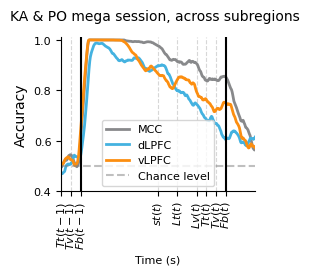

In [ ]:
fig, ax = plt.subplots(figsize=(2.5, 2))

for subregion, data_projected in decodabilities.items():
    data = data_projected.decodability.values
    data = np.convolve(data, np.ones((50,))/50, mode='same')
    ax.plot(data_projected.time.values, data, label=subregion, color=COLORS[subregion], lw=2)


ax.axhline(y=0.5, color='grey', linestyle='--', alpha=0.5, label='Chance level')
    
plot_keypoints(ax, (-1, 0), mark_event='Fb', xlabels='events')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(alpha=0.5, linestyle='--', axis='x')
ax.set_xlim([-5, 5])
ax.set_ylim([0.4, 1.01])
ax.set_xlabel('Time (s)')
ax.set_ylabel('Accuracy', fontsize=10)
ax.legend()

# save figure
plt.suptitle(f'KA & PO mega session, across subregions', fontsize=10, y=1.02)
fig.savefig(f'figs/neural_value/mega_session/KA&PO_mega_session_decodability.svg', bbox_inches='tight', transparent=True)
plt.show()


## Extract neural value

In [ ]:
data_projected

<xarray.DataArray (trial_id: 160, time: 1500)>
array([[ 2.78937215,  4.63717151,  5.33213289, ...,  1.63603636,
         2.28740842,  2.62468522],
       [ 2.45641107,  2.53732883,  3.4767601 , ..., -1.81497964,
        -3.06139228, -4.39829889],
       [ 1.62935095,  1.7241926 ,  0.40615055, ...,  1.43317638,
         1.08831925,  0.76618749],
       ...,
       [ 0.93128683,  1.32776996,  1.30187699, ..., -0.1917541 ,
         0.19353158,  0.80883383],
       [-2.34510266, -4.43194227, -4.84677713, ..., -5.47438616,
        -5.17851522, -4.48357317],
       [ 1.79242847,  1.51132362,  1.3706605 , ...,  0.76974081,
        -0.5995732 , -1.55233628]])
Coordinates:
    history_of_feedback  (trial_id) float64 0.0 0.0 0.0 0.0 ... 7.0 7.0 7.0 7.0
  * trial_id             (trial_id) int64 0 1 2 3 4 5 ... 155 156 157 158 159
    R_1                  (trial_id) int64 0 0 0 0 0 0 0 0 0 ... 1 1 1 1 1 1 1 1
    R_2                  (trial_id) int64 0 0 0 0 0 0 0 0 0 ... 1 1 1 1 1 1 1 1
    R_3                  (trial_id) int64 0 0 0 0 0 0 0 0 0 ... 1 1 1 1 1 1 1 1
    fb_sequence          (trial_id) float64 0.0 0.0 0.0 0.0 ... 7.0 7.0 7.0 7.0
    fb_sequence_m1       (trial_id) float64 0.0 0.0 0.0 0.0 ... 3.0 3.0 3.0 3.0
  * time                 (time) float64 -7.5 -7.49 -7.48 ... 7.47 7.48 7.49
    epoch                (time) float64 0.0 0.0 0.0 0.0 0.0 ... 5.0 5.0 5.0 5.0
    time_m1              (time) float64 0.0 0.01 0.02 0.03 ... 14.97 14.98 14.99
    decodability         (time) float64 0.5375 0.5125 0.5375 ... 0.5687 0.575